
Training set size:  (29305, 14)

Validation set size:  (9768, 14)

Test set size:  (9769, 14)

Training set target proportions (%): 
income
<=50K    76.072343
>50K     23.927657
Name: proportion, dtype: float64

Validation set target proportions (%): 
income
<=50K    76.074939
>50K     23.925061
Name: proportion, dtype: float64

Test set target proportions (%): 
income
<=50K    76.067151
>50K     23.932849
Name: proportion, dtype: float64

Numerical features: 
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features: 
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Dimensionality of the dataset: 
(48842, 14)

Target values: 
income
<=50K    37155
>50K     11687
Name: count, dtype: int64

Target proportions (%): 
income
<=50K    76.071823
>50K     23.928177
Name: proportion, dtype: float64

Training data info: 
<class 'pandas.DataFrame'>
Index: 29305 entries, 47360 to 40003
Da

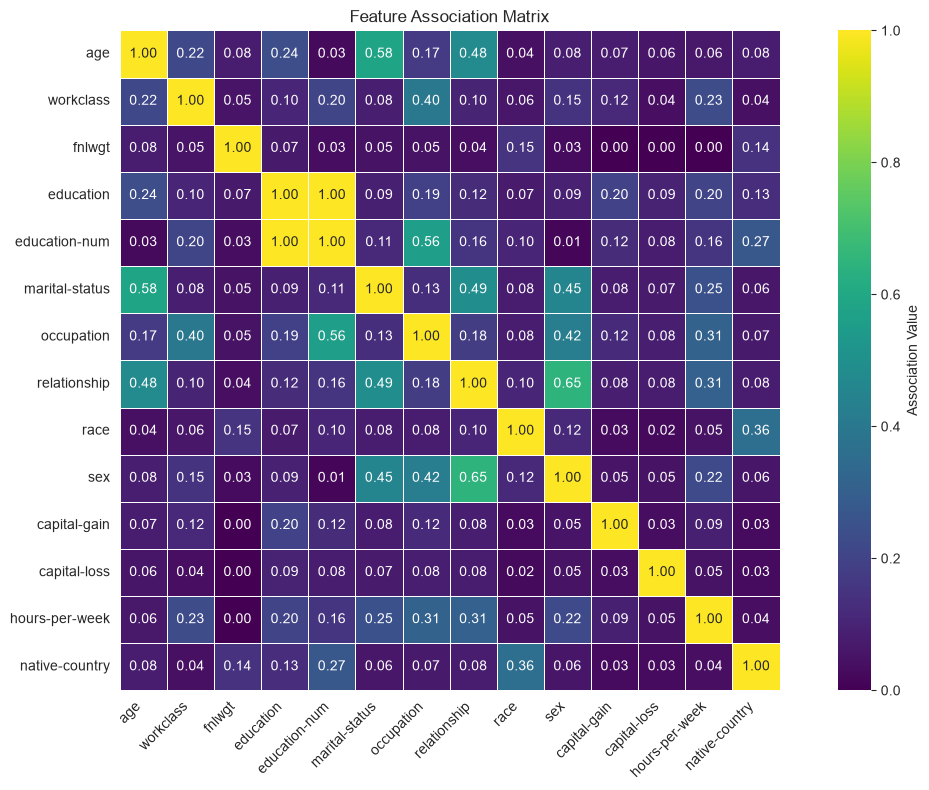


ANOVA results:
          Feature          Test    Statistic        P-value
2   education-num  ANOVA F-test  3690.430802   0.000000e+00
5  hours-per-week  ANOVA F-test  1683.089024   0.000000e+00
0             age  ANOVA F-test  1587.455187   0.000000e+00
3    capital-gain  ANOVA F-test  1522.636222   0.000000e+00
4    capital-loss  ANOVA F-test   651.069650  4.666314e-142
1          fnlwgt  ANOVA F-test     0.455933   4.995362e-01

Chi-square results:
           Feature        Test    Statistic        P-value
7        education  Chi-square  3964.148660   0.000000e+00
8   marital-status  Chi-square  5767.919421   0.000000e+00
9       occupation  Chi-square  3514.073644   0.000000e+00
10    relationship  Chi-square  5942.293271   0.000000e+00
12             sex  Chi-square  1337.575449  7.720376e-293
6        workclass  Chi-square   933.798330  2.887890e-196
11            race  Chi-square   278.963450   3.728004e-59
13  native-country  Chi-square   212.002346   1.376335e-34


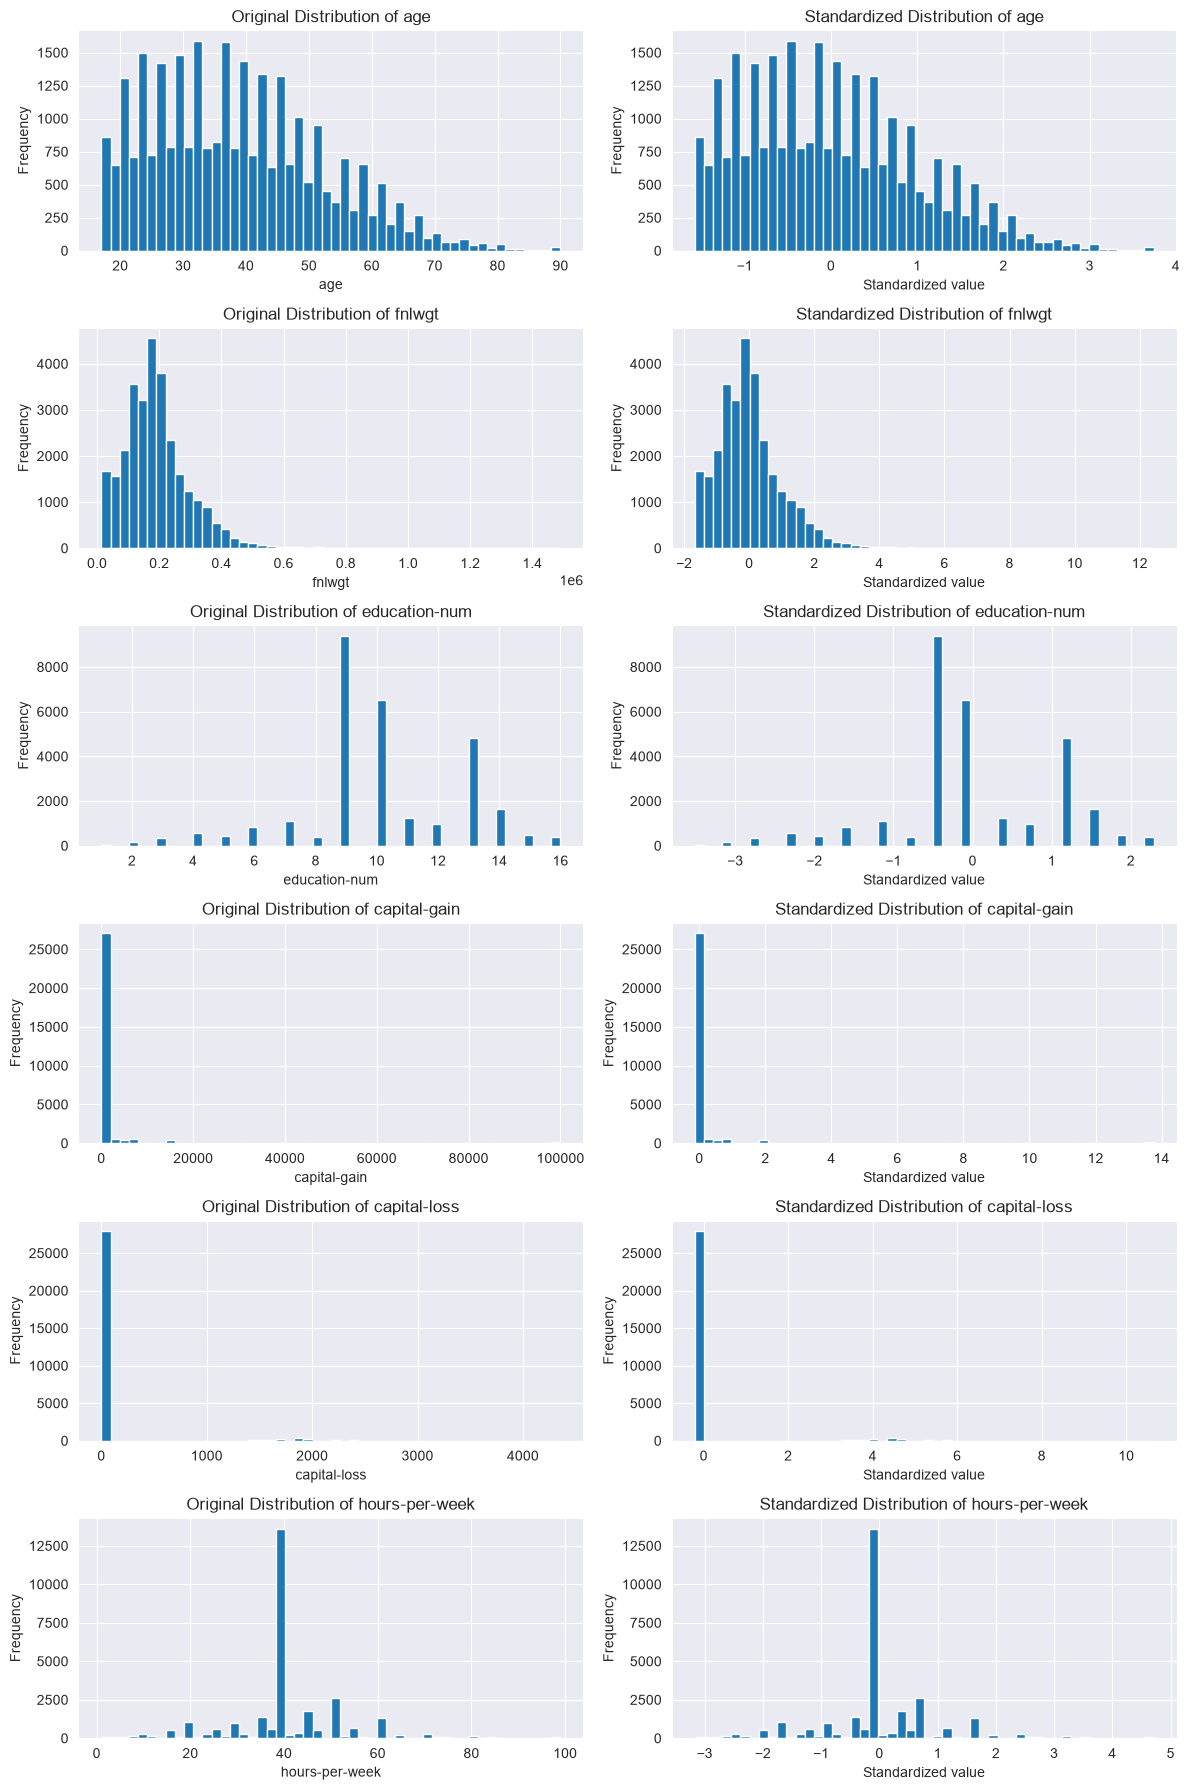


Original:
            age         fnlwgt  education-num  capital-gain  capital-loss  \
mean  38.688654  189643.680566      10.084559   1042.943934     86.725371   
std   13.711323  104656.374996       2.584792   7191.128295    400.907514   

      hours-per-week  
mean       40.461525  
std        12.431910  

Standardized mean:
age              -5.285730e-17
fnlwgt            8.801468e-17
education-num    -2.560427e-16
capital-gain     -2.182182e-18
capital-loss     -3.030808e-17
hours-per-week    2.043977e-16
dtype: float64

Standardized std:
age               1.0
fnlwgt            1.0
education-num     1.0
capital-gain      1.0
capital-loss      1.0
hours-per-week    1.0
dtype: float64

SVM preprocessing:
Training: (29305, 86)
Validation: (9768, 86)
Test: (9769, 86)

DT preprocessing:
Training: (29305, 86)
Validation: (9768, 86)
Test: (9769, 86)


In [5]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats.contingency import association
from scipy.stats import f_oneway, chi2_contingency
from itertools import combinations
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
MULTIPLIER_100 = 100

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features.copy() # copy to avoid side effects.
y = adult.data.targets.squeeze().copy()  # convert to 1D array,
                                         # copy to avoid side effects.

###############################
# Dataset cleanup
###############################

# normalize target labels, to only have two target classes: <=50K and >50K
y = y.str.strip().str.rstrip(".")
# replace missing "?" values with NaN
X = X.replace("?", np.nan)

###############################
# 60/20/20 stratified split
###############################

# training set, using 60% of the data
X_train, X_temp, y_train, y_temp = train_test_split(X,
                                                    y,
                                                    test_size=0.4,
                                                    stratify=y, # stratify using target label
                                                                # that corresponds to the data
                                                                # that is split.
                                                    random_state=RANDOM_STATE)

# validation set and test set, each using 20% of the data
X_val, X_test, y_val, y_test = train_test_split(X_temp,
                                                y_temp,
                                                test_size=0.5,
                                                stratify=y_temp, # stratify only on the temporary 40%
                                                                 # of the data.
                                                random_state=RANDOM_STATE)

###############################
# Verify splits
###############################

print("\nTraining set size: ", X_train.shape)
print("\nValidation set size: ", X_val.shape)
print("\nTest set size: ", X_test.shape)

print("\nTraining set target proportions (%): ")
print(y_train.value_counts(normalize=True) * MULTIPLIER_100)

print("\nValidation set target proportions (%): ")
print(y_val.value_counts(normalize=True) * MULTIPLIER_100)

print("\nTest set target proportions (%): ")
print(y_test.value_counts(normalize=True) * MULTIPLIER_100)

###############################
# Identify feature types
###############################

num_features = X_train.select_dtypes(
    include=["number"]
).columns

categ_features = X_train.select_dtypes(
    include=["str", "category"]
).columns

print("\nNumerical features: ")
print(num_features.tolist())

print("\nCategorical features: ")
print(categ_features.tolist())

###############################
# Inspect the dataset
###############################

print("\nDimensionality of the dataset: ")
print(X.shape)

print("\nTarget values: ")
print(y.value_counts())

print("\nTarget proportions (%): ")
print(y.value_counts(normalize=True) * MULTIPLIER_100)

################################
# Inspect training data
################################

print("\nTraining data info: ")
X_train.info()

num_summary = X_train.describe().T
print("\nNumerical features X_train: ")
print(num_summary)

categ_summary = X_train.describe(include=["str", "category"]).T
print("\nCategorical features X_train: ")
print(categ_summary)

################################
# Q1.1 - Missing values
################################

print("\nMissing values in X_train: ")
print(X_train.isna().sum())

print("\nTotal missing values in X_train:")
print(X_train.isna().sum().sum())

print("\nMissing values in y_train:")
print(y_train.isna().sum())

missing_summary = pd.DataFrame({
    "Missing count": X_train.isna().sum(),
    "Missing (%)": X_train.isna().mean() * MULTIPLIER_100
})

missing_summary = missing_summary[missing_summary["Missing count"] > 0]
print(missing_summary)

# check if occupation missingness is associated with workclass
print("\nOccupation missingness in workclass:")
occupation_missing_in_workclass = pd.crosstab(
    X_train["workclass"].fillna("Missing"),
    X_train["occupation"].isna(),
    normalize="index"
) * MULTIPLIER_100
print(occupation_missing_in_workclass)

# compare native-country missingness across workclass groups
print("\nNative country missingness in workclass:")
native_contry_missing_in_workclass = pd.crosstab(
    X_train["workclass"].fillna("Missing"),
    X_train["native-country"].isna(),
    normalize="index"
) * MULTIPLIER_100
print(native_contry_missing_in_workclass)

# check joint missingness of workclass and occupation
print("\nJoint missingness of workclass and occupation:")
joint_missing = pd.crosstab(
    X_train["workclass"].isna(),
    X_train["occupation"].isna(),
)
print(joint_missing)

###############################
# Q1.2 - Outlier detection
###############################

QUARTILE_RANGE_MULTIPLIER = 1.5

outlier_summary = []

for feature in num_features:
    q1 = X_train[feature].quantile(0.25)
    q3 = X_train[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - QUARTILE_RANGE_MULTIPLIER * iqr
    upper_bound = q3 + QUARTILE_RANGE_MULTIPLIER * iqr

    iqr_outliers = (
        (X_train[feature] < lower_bound) |
        (X_train[feature] > upper_bound)
    ).sum()

    mean = X_train[feature].mean()
    std = X_train[feature].std()

    z_score = (X_train[feature] - mean) / std
    z_outliers = (z_score.abs() > 3).sum()

    outlier_summary.append({
        "Feature": feature,
        "IQR outliers": iqr_outliers,
        "Z-score outliers": z_outliers
    })

outlier_summary = pd.DataFrame(outlier_summary)
print("\n", outlier_summary)
print("\nq1 and q3 for capital-gain and capital-loss:")
print(X_train[["capital-gain", "capital-loss"]].quantile([0.25, 0.75]))
print("\nq1 and q3 for hours-per-week:")
print(X_train["hours-per-week"].quantile([0.25, 0.75]))
print("\nq1 and q3 for education-num:")
print(X_train["education-num"].quantile([0.25, 0.75]))

####################################
# Q1.3 - Cardinality quantification
####################################

X_train_cat = X_train[categ_features].fillna("Missing").copy()

# compute the cardinality of each categorical feature
cardinality = X_train_cat.nunique().sort_values(ascending=False)

print("\nCategorical feature cardinality:")
print(cardinality)

CANDIDATE_THRESHOLDS = [10, 25, 50, 100, 250]

def threshold_summary(series, thresholds):
    counts = series.value_counts()
    original_cardinality = len(counts)
    n_observations = len(series)

    results = []

    for threshold in thresholds:
        rare_counts = counts[counts < threshold]

        n_rare_categories = len(rare_counts)
        n_grouped_observations = rare_counts.sum()

        if n_rare_categories > 0:
            cardinality_after = (
                original_cardinality - n_rare_categories + 1
            )
        else:
            cardinality_after = original_cardinality

        results.append({
            "Threshold": threshold,
            "Min support (%)":
                threshold / n_observations * 100,
            "Rare categories":
                n_rare_categories,
            "Observations grouped":
                n_grouped_observations,
            "Observations grouped (%)":
                n_grouped_observations / n_observations * 100,
            "Cardinality before":
                original_cardinality,
            "Cardinality after":
                cardinality_after,
            "Cardinality reduction (%)":
                (
                    (original_cardinality - cardinality_after)
                    / original_cardinality
                    * 100
                )
        })

    return pd.DataFrame(results)


native_country_thresholds = threshold_summary(
    X_train_cat["native-country"],
    CANDIDATE_THRESHOLDS
)

occupation_thresholds = threshold_summary(
    X_train_cat["occupation"],
    CANDIDATE_THRESHOLDS
)

print("\nThreshold comparison - native-country:")
print(native_country_thresholds)

print("\nThreshold comparison - occupation:")
print(occupation_thresholds)

# group rare categories in native-country and occupation features
RARE_CATEGORY_THRESHOLD = 50

native_country_counts = X_train_cat["native-country"].value_counts()

# use the index of the value counts to get the rare categories
rare_countries = native_country_counts[
    native_country_counts < RARE_CATEGORY_THRESHOLD
].index

# group rare categories into "Other" category
native_country_grouped = X_train_cat["native-country"].where(
    ~X_train_cat["native-country"].isin(rare_countries),
    "Other"
)

print("\nnative-country categories before grouping:")
print(X_train_cat["native-country"].nunique())

print("\nRare native-country categories:")
print(len(rare_countries))

print("\nObservations grouped into Other:")
print(X_train_cat["native-country"].isin(rare_countries).sum())

print("\nnative-country categories after grouping:")
print(native_country_grouped.nunique())

print("\nnative-country counts after grouping:")
print(native_country_grouped.value_counts())

occupation_counts = X_train_cat["occupation"].value_counts()

rare_occupations = occupation_counts[
    occupation_counts < RARE_CATEGORY_THRESHOLD
]

print("\nRare occupation categories:")
print(rare_occupations)

print("\nOccupation categories before grouping:")
print(X_train_cat["occupation"].nunique())

# group rare categories into "Other" category
occupation_grouped = X_train_cat["occupation"].where(
    ~X_train_cat["occupation"].isin(rare_occupations.index),
    "Other"
)

print("\nOccupation categories after grouping:")
print(occupation_grouped.nunique())

####################################
# Q1.4 - Categorical encoding
####################################

X_train_cat_grouped = X_train_cat.copy()

X_train_cat_grouped["native-country"] = native_country_grouped

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

# fit the one-hot encoder with the grouped categorical features
X_train_cat_encoded = one_hot_encoder.fit_transform(
    X_train_cat_grouped
)

print("\nCategorical columns before encoding:")
print(X_train_cat_grouped.shape[1])

print("\nCategorical features after one-hot encoding:")
print(X_train_cat_encoded.shape[1])

# display dimensionality of the dataset before and after one-hot encoding
categories_before = X_train_cat.nunique().sum()
categories_after = X_train_cat_grouped.nunique().sum()

print("\nOne-hot features before rare-category grouping:")
print(categories_before)

print("\nOne-hot features after rare-category grouping:")
print(categories_after)

print("\nTotal features after adding numerical features:")
print(categories_after + len(num_features))

###############################
# Q1.5 - Association analysis
###############################

X_association = X_train.copy()

X_association[categ_features] = (X_association[categ_features].fillna("Missing"))

# apply rare-category strategy to native-country
X_association["native-country"] = (
    X_association["native-country"].where(
        ~X_association["native-country"].isin(rare_countries),
        "Other"
    )
)

# calculate Cramer's V for association between two categorical features
def cramers_v(x, y):
    # create contingency table and calculate Cramer's V
    return association(
        pd.crosstab(x, y),
        method="cramer"
    )

# calculate correlation ratio between a categorical and numerical feature
def correlation_ratio(categories, values):
    # combine categorical and numerical values, remove missing rows
    data = pd.DataFrame({
        "category": categories,
        "value": values
    }).dropna()

    overall_mean = data["value"].mean()

    # calculate variation between the means of each category
    between_variation = sum(
        len(group) * (group.mean() - overall_mean) ** 2
        for _, group in data.groupby("category")["value"]
    )

    total_variation = (
        (data["value"] - overall_mean) ** 2
    ).sum()

    # handle zero-division case
    if total_variation == 0:
        return 0.0

    # calculate correlation ratio, range from 0 to 1
    return np.sqrt(
        between_variation / total_variation
    )

features = X_association.columns

# initialize association matrix, with diagonal values set to 1.0
association_matrix = pd.DataFrame(
    np.eye(len(features)),
    index=features,
    columns=features
)

# compute association values for each pair of features
for feature_1, feature_2 in combinations(features, 2):

    # numerical - numerical -> Pearson correlation
    if feature_1 in num_features and feature_2 in num_features:
        value = abs(
            X_association[feature_1].corr(
                X_association[feature_2]
            )
        )

    # categorical - categorical -> Cramer's V
    elif feature_1 in categ_features and feature_2 in categ_features:
        value = cramers_v(
            X_association[feature_1],
            X_association[feature_2]
        )

    # categorical - numerical -> correlation ratio
    else:
        if feature_1 in categ_features:
            categorical_feature = feature_1
            numerical_feature = feature_2
        else:
            categorical_feature = feature_2
            numerical_feature = feature_1

        value = correlation_ratio(
            X_association[categorical_feature],
            X_association[numerical_feature]
        )

    # matrix is symmetric, store association in both [i, j] and [j, i] positions
    association_matrix.loc[feature_1, feature_2] = value
    association_matrix.loc[feature_2, feature_1] = value

plt.figure(figsize=(12, 8))

sns.heatmap(association_matrix,
            annot=True,
            fmt=".2f",
            cmap="viridis",
            cbar_kws={"label": "Association Value"},
            vmin=0,
            vmax=1,
            square=True,
            linewidths=0.5)

plt.title("Feature Association Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

####################################
# Q1.6 - Statistical association
####################################

X_statistical = X_train.copy()

# apply missing-value strategy
X_statistical[categ_features] = (
    X_statistical[categ_features].fillna("Missing")
)

# apply rare-category strategy
X_statistical["native-country"] = (
    X_statistical["native-country"].where(
        ~X_statistical["native-country"].isin(rare_countries),
        "Other"
    )
)

statistical_results = []

# numerical features: ANOVA F-test
for feature in num_features:

    # separate feature values by target class
    group_low = X_statistical.loc[
        y_train == "<=50K", feature
    ].dropna()

    group_high = X_statistical.loc[
        y_train == ">50K", feature
    ].dropna()

    # test if feature means differ between target classes
    statistic, p_value = f_oneway(
        group_low,
        group_high
    )

    statistical_results.append({
        "Feature": feature,
        "Test": "ANOVA F-test",
        "Statistic": statistic,
        "P-value": p_value
    })

# categorical features: chi-square test
for feature in categ_features:

    contingency_table = pd.crosstab(
        X_statistical[feature],
        y_train
    )

    # test categorical feature independence from target class
    statistic, p_value, _, _ = chi2_contingency(
        contingency_table
    )

    statistical_results.append({
        "Feature": feature,
        "Test": "Chi-square",
        "Statistic": statistic,
        "P-value": p_value
    })

statistical_results = pd.DataFrame(
    statistical_results
)

anova_results = statistical_results[
    statistical_results["Test"] == "ANOVA F-test"
].sort_values(
    by="Statistic",
    ascending=False
)

chi_square_results = statistical_results[
    statistical_results["Test"] == "Chi-square"
].sort_values(
    by="P-value"
)

print("\nANOVA results:")
print(anova_results)

print("\nChi-square results:")
print(chi_square_results)

#####################################
# Q1.7 - numerical feature analysis
#####################################

X_num = X_train[num_features].copy()

scaler = StandardScaler()

X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X_num),
    columns=num_features,
    index=X_num.index
)

fig, ax = plt.subplots(
    len(num_features),
    2,
    figsize=(12, 3 * len(num_features))
)

for i, feature in enumerate(num_features):

    # original distribution
    ax[i, 0].hist(
        X_num[feature],
        bins=50
    )

    ax[i, 0].set_title(f"Original Distribution of {feature}")
    ax[i, 0].set_xlabel(feature)
    ax[i, 0].set_ylabel("Frequency")

    # standardized distribution
    ax[i, 1].hist(
        X_num_scaled[feature],
        bins=50
    )

    ax[i, 1].set_title(f"Standardized Distribution of {feature}")
    ax[i, 1].set_xlabel("Standardized value")
    ax[i, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("\nOriginal:")
print(
    X_num.agg(["mean", "std"])
)

print("\nStandardized mean:")
print(X_num_scaled.mean())

print("\nStandardized std:")
print(X_num_scaled.std(ddof=0))

#################################
# Q1.8 - Preprocessing pipelines
#################################

# outliers are kept as decided in Q1.2,
# so no outlier-removal or capping step is included

# categorical features except native-country
non_native_country_categ_features = [
    feature for feature in categ_features
    if feature != "native-country"
]

# numerical preprocessing for SVM
num_svm_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# numerical preprocessing for DT
num_dt_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# categorical preprocessing
categ_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# native-country preprocessing with rare-category handling
native_country_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="infrequent_if_exist", # replace manual rare-category handling
            min_frequency=RARE_CATEGORY_THRESHOLD
        )
    )
])

svm_preprocessor = ColumnTransformer([
    (
        "numerical",
        num_svm_pipeline,
        num_features
    ),
    (
        "categorical",
        categ_pipeline,
        non_native_country_categ_features
    ),
    (
        "native-country",
        native_country_pipeline,
        ["native-country"]
    )
])

dt_preprocessor = ColumnTransformer([
    (
        "numerical",
        num_dt_pipeline,
        num_features
    ),
    (
        "categorical",
        categ_pipeline,
        non_native_country_categ_features
    ),
    (
        "native-country",
        native_country_pipeline,
        ["native-country"]
    )
])

# combining preprocessing and the model ensures that preprocessing
# is fit separately on each training-fold during cross-validation.

svm_pipeline = Pipeline([
    (
        "preprocessor",
        svm_preprocessor
    ),
    (
        "model",
        SVC()
    )
])

dt_pipeline = Pipeline([
    (
        "preprocessor",
        dt_preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )
    )
])

# demonstrate preprocessing for the outer train/validation/test split,
# preprocessing is fitted only on X_train and reused unchanged for
# X_val and X_test

X_train_svm_processed = svm_preprocessor.fit_transform(X_train)
X_val_svm_processed = svm_preprocessor.transform(X_val)
X_test_svm_processed = svm_preprocessor.transform(X_test)

X_train_dt_processed = dt_preprocessor.fit_transform(X_train)
X_val_dt_processed = dt_preprocessor.transform(X_val)
X_test_dt_processed = dt_preprocessor.transform(X_test)

print("\nSVM preprocessing:")
print("Training:", X_train_svm_processed.shape)
print("Validation:", X_val_svm_processed.shape)
print("Test:", X_test_svm_processed.shape)

print("\nDT preprocessing:")
print("Training:", X_train_dt_processed.shape)
print("Validation:", X_val_dt_processed.shape)
print("Test:", X_test_dt_processed.shape)
